# 🎬 Netflix Prize Recommendation System

**Dataset:** Netflix Prize (100M+ ratings, 480K users, 17K movies)  
**Models:** SVD (Matrix Factorisation) · Item-Based Collaborative Filtering  
**Evaluation:** RMSE · MAE · MAP@10 · Precision@10 · Recall@10 · NDCG@10 · Hit Rate · Coverage

---
## Table of Contents
1. [Setup & Imports](#1-setup)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Data Preprocessing & Split](#4-preprocessing)
5. [Model 1: SVD (Matrix Factorisation)](#5-svd)
6. [Model 2: Item-Based Collaborative Filtering](#6-itemcf)
7. [Model Evaluation & Comparison](#7-evaluation)
8. [Top-K Recommendations](#8-recommendations)
9. [Explainability](#9-explainability)
10. [Qualitative Analysis](#10-analysis)
11. [Summary & Conclusions](#11-summary)

## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
# ── Install dependencies (Colab) ──────────────────────────────────────────
!pip install scikit-surprise tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.3 MB/s eta 0:00:00


In [49]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
SEED = 42
np.random.seed(SEED)


from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/archive'


DATA_DIR = os.environ.get('NETFLIX_DATA_DIR', './data')  # folder containing combined_data_*.txt + movie_titles.csv

print('✓ Setup complete')
print(f'  Working directory : {os.getcwd()}')
print(f'  Data directory    : {DATA_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Setup complete
  Working directory : /content
  Data directory    : ./data


In [6]:

def add_src_to_path():
    """Try to import from src/ first; return True if successful."""
    for candidate in ['.', '..', '/content']:
        src = os.path.join(candidate, 'src')
        if os.path.isdir(src):
            sys.path.insert(0, candidate)
            return True
    return False

USE_SRC = add_src_to_path()
print('✓ src/ package found — importing modules' if USE_SRC
      else '  src/ not found — using inline implementations')

  src/ not found — using inline implementations


## 2. Data Loading <a id='2-data-loading'></a>

In [8]:

from typing import List, Optional, Tuple, Dict


def parse_netflix_file(filepath: str, max_rows: Optional[int] = None) -> pd.DataFrame:
    """Parse a single combined_data_N.txt file."""
    records, movie_id, rows_loaded = [], None, 0
    with open(filepath, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                parts = line.split(',')
                if len(parts) == 3 and movie_id is not None:
                    try:
                        records.append((movie_id, int(parts[0]), int(parts[1]), parts[2]))
                        rows_loaded += 1
                        if max_rows and rows_loaded >= max_rows:
                            break
                    except ValueError:
                        continue
    return pd.DataFrame(records, columns=['movie_id', 'user_id', 'rating', 'date'])


def load_netflix_data(data_dir: str,
                      files: Optional[List[str]] = None,
                      max_rows: Optional[int] = None) -> pd.DataFrame:
    """Load one or more Netflix Prize combined_data files."""
    if files is None:
        files = [f'combined_data_{i}.txt' for i in range(1, 5)]
    dfs, total = [], 0
    for fname in files:
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            print(f'  [skip] {fname} not found'); continue
        remaining = (max_rows - total) if max_rows else None
        if remaining is not None and remaining <= 0:
            break
        print(f'  Loading {fname} ...', end=' ')
        df = parse_netflix_file(fpath, max_rows=remaining)
        dfs.append(df); total += len(df)
        print(f'{len(df):,} rows  (running total: {total:,})')
        if max_rows and total >= max_rows:
            break
    if not dfs:
        raise FileNotFoundError(
            f"No Netflix data files found in '{data_dir}'.\n"
            "Download from: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data")
    combined = pd.concat(dfs, ignore_index=True)
    combined['date'] = pd.to_datetime(combined['date'], errors='coerce')
    print(f'\n✓  Total loaded  : {len(combined):,} ratings'
          f'\n   Unique users  : {combined["user_id"].nunique():,}'
          f'\n   Unique movies : {combined["movie_id"].nunique():,}')
    return combined


def load_movie_titles(data_dir: str) -> pd.DataFrame:
    """Load movie_titles.csv."""
    fpath = os.path.join(data_dir, 'movie_titles.csv')
    try:
        df = pd.read_csv(fpath, encoding='latin-1', header=None,
                         names=['movie_id', 'year', 'title'], on_bad_lines='skip')
        df['year'] = pd.to_numeric(df['year'], errors='coerce')
        print(f'✓  Loaded {len(df):,} movie titles')
        return df
    except FileNotFoundError:
        print('Warning: movie_titles.csv not found.')
        return pd.DataFrame(columns=['movie_id', 'year', 'title'])


def get_subset(df: pd.DataFrame,
               n_users: int = 3000, n_movies: int = 1500,
               min_user_ratings: int = 30, min_movie_ratings: int = 100) -> pd.DataFrame:
    """Select a computationally manageable dense subset."""
    user_cnt = df['user_id'].value_counts()
    movie_cnt = df['movie_id'].value_counts()
    active_users  = user_cnt[user_cnt >= min_user_ratings].nlargest(n_users).index
    popular_movies = movie_cnt[movie_cnt >= min_movie_ratings].nlargest(n_movies).index
    subset = df[df['user_id'].isin(active_users) & df['movie_id'].isin(popular_movies)].copy()
    n_u, n_m, n_r = subset['user_id'].nunique(), subset['movie_id'].nunique(), len(subset)
    density = n_r / (n_u * n_m) if n_u * n_m > 0 else 0
    print(f'✓  Subset: {n_u:,} users × {n_m:,} movies → {n_r:,} ratings '
          f'(density {density:.3%}, sparsity {1-density:.3%})')
    return subset


def temporal_train_test_split(df: pd.DataFrame,
                               test_ratio: float = 0.2) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Temporal split per user (train on past, test on future)."""
    train_parts, test_parts = [], []
    for _, user_df in df.groupby('user_id'):
        s = user_df.sort_values('date')
        n = len(s)
        if n < 5:
            train_parts.append(s); continue
        split_idx = max(2, int(n * (1 - test_ratio)))
        train_parts.append(s.iloc[:split_idx])
        test_parts.append(s.iloc[split_idx:])
    train = pd.concat(train_parts, ignore_index=True)
    test  = pd.concat(test_parts,  ignore_index=True) if test_parts else pd.DataFrame()
    print(f'✓  Train: {len(train):,} ratings ({len(train)/len(df):.1%})  '
          f'| Test: {len(test):,} ratings ({len(test)/len(df):.1%})')
    return train, test


print('✓ Data-loading utilities defined')

✓ Data-loading utilities defined


In [10]:
# ── Loading  a manageable slice from the full dataset ────────────────────────
# max_rows=5_000_000 gives ~5 M ratings — enough for meaningful modelling


print('=' * 60)
print('  Loading Netflix Prize Dataset')
print('=' * 60)

raw_df = load_netflix_data(DATA_DIR, max_rows=5_000_000)

# Load movie metadata
movies_df  = load_movie_titles(DATA_DIR)
movie_titles: Dict[int, str] = dict(zip(movies_df['movie_id'], movies_df['title']))

print(f'\nSample rows:')
raw_df.head()

  Loading Netflix Prize Dataset
  Loading combined_data_1.txt ... 5,000,000 rows  (running total: 5,000,000)

✓  Total loaded  : 5,000,000 ratings
   Unique users  : 404,478
   Unique movies : 996
✓  Loaded 17,434 movie titles

Sample rows:


,movie_id,user_id,rating,date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [11]:
# ── Create subset for modelling ───────────────────────────────────────────
print('Creating dense subset for modelling...')
df = get_subset(raw_df, n_users=3000, n_movies=1500,
                min_user_ratings=30, min_movie_ratings=100)

del raw_df   # free memory
import gc; gc.collect()

df.info()

Creating dense subset for modelling...
✓  Subset: 3,000 users × 942 movies → 340,769 ratings (density 12.058%, sparsity 87.942%)
<class 'pandas.core.frame.DataFrame'>
Index: 340769 entries, 0 to 4999974
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  340769 non-null  int64         
 1   user_id   340769 non-null  int64         
 2   rating    340769 non-null  int64         
 3   date      340769 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 13.0 MB


## 3. Exploratory Data Analysis <a id='3-eda'></a>

## 3.2 Basic Statistics

In [14]:

n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
density  = n_ratings / (n_users * n_movies)

print('=' * 55)
print('  Dataset Statistics (subset)')
print('=' * 55)
print(f'  Ratings          : {n_ratings:>12,}')
print(f'  Unique users     : {n_users:>12,}')
print(f'  Unique movies    : {n_movies:>12,}')
print(f'  Matrix density   : {density:>12.4%}')
print(f'  Matrix sparsity  : {1-density:>12.4%}')
print(f'  Rating range     : {df["rating"].min()} – {df["rating"].max()}')
print(f'  Mean rating      : {df["rating"].mean():.4f}')
print(f'  Median rating    : {df["rating"].median():.1f}')
print(f'  Std dev          : {df["rating"].std():.4f}')
print(f'  Date range       : {df["date"].min().date()} → {df["date"].max().date()}')
print('=' * 55)
df['rating'].describe()

  Dataset Statistics (subset)
  Ratings          :      340,769
  Unique users     :        3,000
  Unique movies    :          942
  Matrix density   :     12.0584%
  Matrix sparsity  :     87.9416%
  Rating range     : 1 – 5
  Mean rating      : 3.3040
  Median rating    : 3.0
  Std dev          : 1.1460
  Date range       : 1999-12-30 → 2005-12-31


,rating
count,340769.0000
mean,3.3040
std,1.1460
min,1.0000
25%,3.0000
50%,3.0000
75%,4.0000
max,5.0000


## 3.2 Rating, User Activity & Movie Popularity Distributions

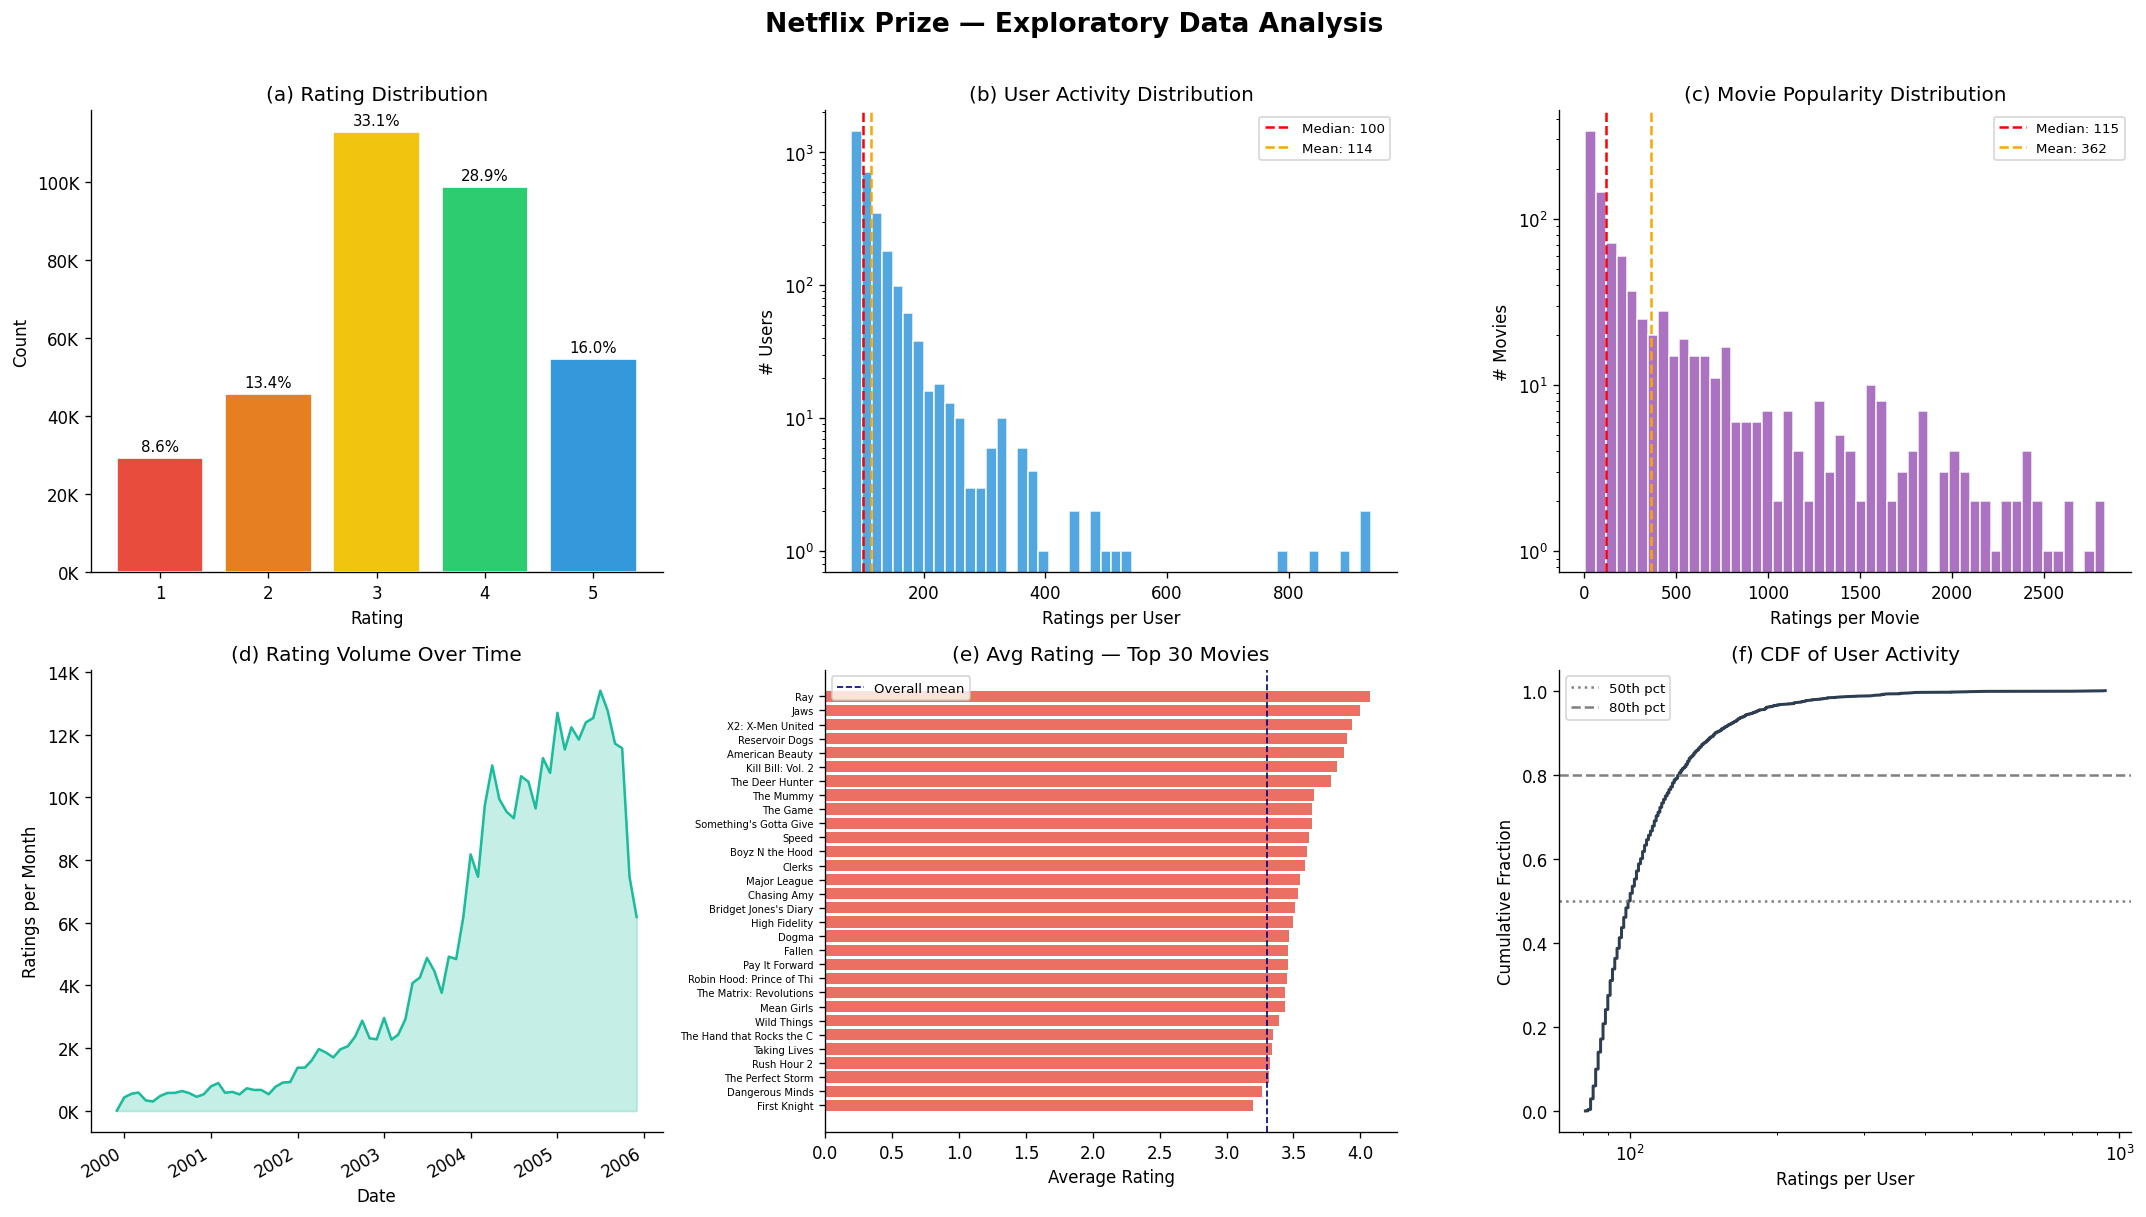

✓ EDA plot saved to eda_overview.png


In [15]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Netflix Prize — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# (a) Rating distribution
ax = axes[0, 0]
rating_counts = df['rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'], edgecolor='white')
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_ratings*0.003,
            f'{val/n_ratings:.1%}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
ax.set_title('(a) Rating Distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# (b) Ratings per user (log scale)
ax = axes[0, 1]
user_counts = df['user_id'].value_counts()
ax.hist(user_counts, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(user_counts.median(), color='red', linestyle='--', label=f'Median: {user_counts.median():.0f}')
ax.axvline(user_counts.mean(), color='orange', linestyle='--', label=f'Mean: {user_counts.mean():.0f}')
ax.set_xlabel('Ratings per User'); ax.set_ylabel('# Users')
ax.set_title('(b) User Activity Distribution')
ax.legend(fontsize=8); ax.set_yscale('log')

# (c) Ratings per movie (log scale)
ax = axes[0, 2]
movie_counts = df['movie_id'].value_counts()
ax.hist(movie_counts, bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(movie_counts.median(), color='red', linestyle='--', label=f'Median: {movie_counts.median():.0f}')
ax.axvline(movie_counts.mean(), color='orange', linestyle='--', label=f'Mean: {movie_counts.mean():.0f}')
ax.set_xlabel('Ratings per Movie'); ax.set_ylabel('# Movies')
ax.set_title('(c) Movie Popularity Distribution')
ax.legend(fontsize=8); ax.set_yscale('log')

# (d) Ratings over time
ax = axes[1, 0]
df_time = df.dropna(subset=['date'])
df_time['year_month'] = df_time['date'].dt.to_period('M')
monthly = df_time.groupby('year_month').size()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, color='#1abc9c', linewidth=1.5)
ax.fill_between(monthly.index, monthly.values, alpha=0.25, color='#1abc9c')
ax.set_xlabel('Date'); ax.set_ylabel('Ratings per Month')
ax.set_title('(d) Rating Volume Over Time')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# (e) Average rating per movie (top 30 most-rated)
ax = axes[1, 1]
top_movies = movie_counts.head(30).index
avg_ratings = df[df['movie_id'].isin(top_movies)].groupby('movie_id')['rating'].mean()
avg_ratings = avg_ratings.sort_values(ascending=True)
labels = [movie_titles.get(m, str(m))[:25] for m in avg_ratings.index]
ax.barh(range(len(labels)), avg_ratings.values, color='#e74c3c', alpha=0.8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=6)
ax.axvline(df['rating'].mean(), color='navy', linestyle='--', linewidth=1, label='Overall mean')
ax.set_xlabel('Average Rating'); ax.set_title('(e) Avg Rating — Top 30 Movies')
ax.legend(fontsize=8)

# (f) CDF of user activity
ax = axes[1, 2]
sorted_uc = np.sort(user_counts.values)
cdf = np.arange(1, len(sorted_uc)+1) / len(sorted_uc)
ax.plot(sorted_uc, cdf, color='#2c3e50', linewidth=1.8)
ax.axhline(0.5, color='gray', linestyle=':', label='50th pct')
ax.axhline(0.8, color='gray', linestyle='--', label='80th pct')
ax.set_xlabel('Ratings per User'); ax.set_ylabel('Cumulative Fraction')
ax.set_title('(f) CDF of User Activity')
ax.legend(fontsize=8); ax.set_xscale('log')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ EDA plot saved to eda_overview.png')

## 3.3 Rating matrix sparsity heatmap

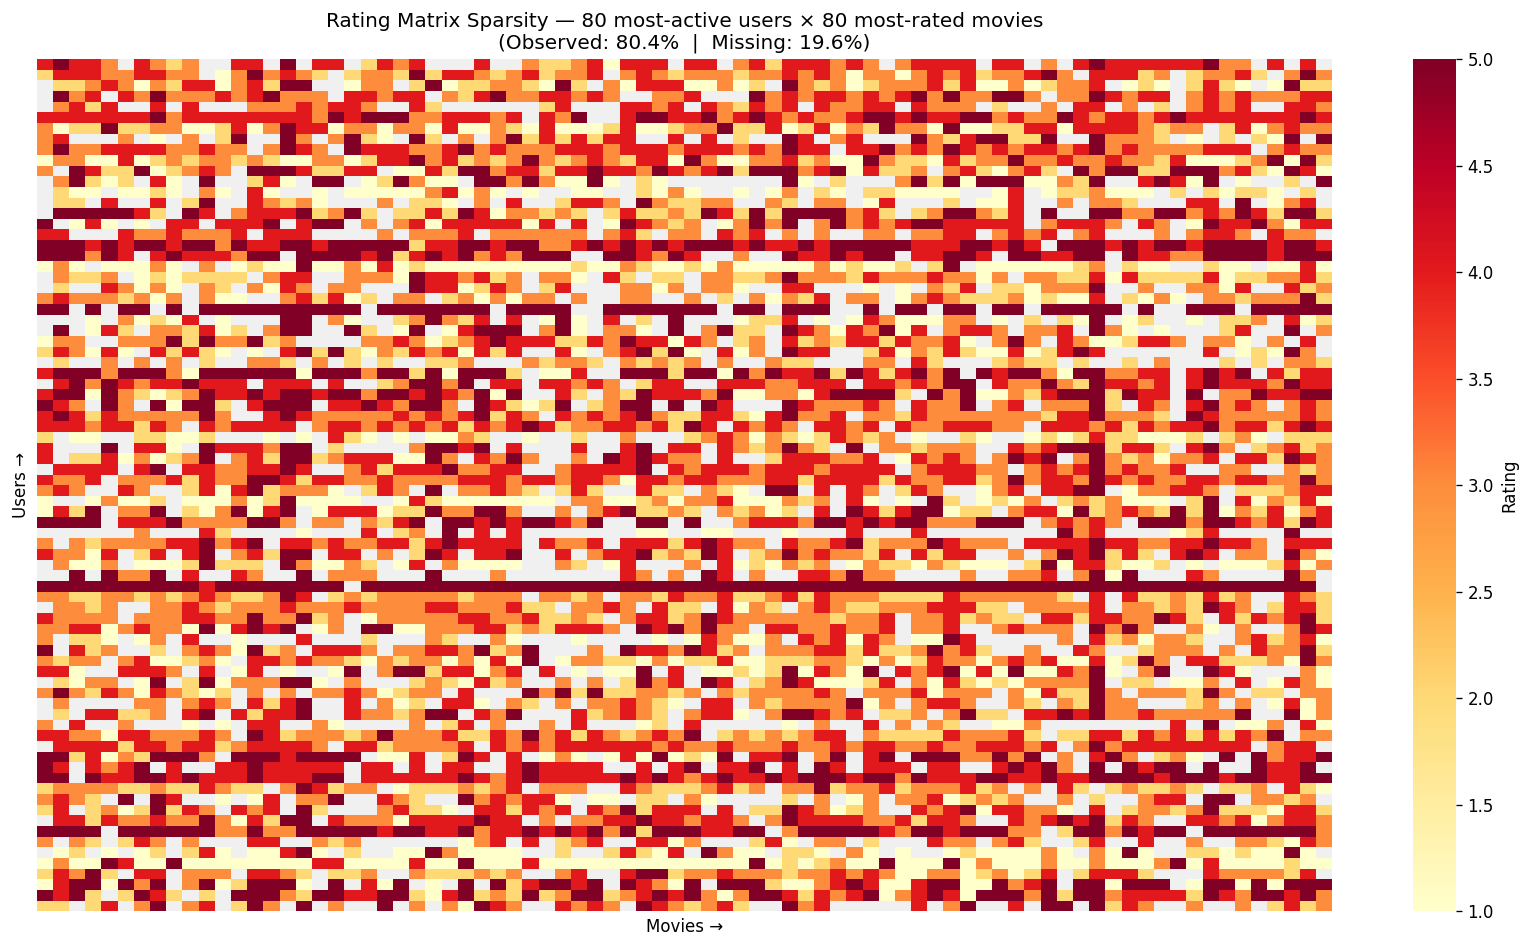

In [16]:

SAMPLE_USERS  = 80
SAMPLE_MOVIES = 80

sample_users  = df['user_id'].value_counts().head(SAMPLE_USERS).index
sample_movies = df['movie_id'].value_counts().head(SAMPLE_MOVIES).index

sample_df = df[df['user_id'].isin(sample_users) & df['movie_id'].isin(sample_movies)]
pivot = sample_df.pivot_table(index='user_id', columns='movie_id', values='rating')

fig, ax = plt.subplots(figsize=(14, 8))
mask = pivot.isna()
sns.heatmap(pivot, mask=mask, cmap='YlOrRd', linewidths=0,
            annot=False, cbar_kws={'label': 'Rating'},
            xticklabels=False, yticklabels=False, ax=ax)
# Show empty cells in light grey
ax.set_facecolor('#f0f0f0')
observed_pct = (~mask).values.sum() / mask.size
ax.set_title(
    f'Rating Matrix Sparsity — {SAMPLE_USERS} most-active users × {SAMPLE_MOVIES} most-rated movies\n'
    f'(Observed: {observed_pct:.1%}  |  Missing: {1-observed_pct:.1%})',
    fontsize=12)
ax.set_xlabel('Movies →'); ax.set_ylabel('Users →')
plt.tight_layout()
plt.savefig('sparsity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4  Temporal patterns

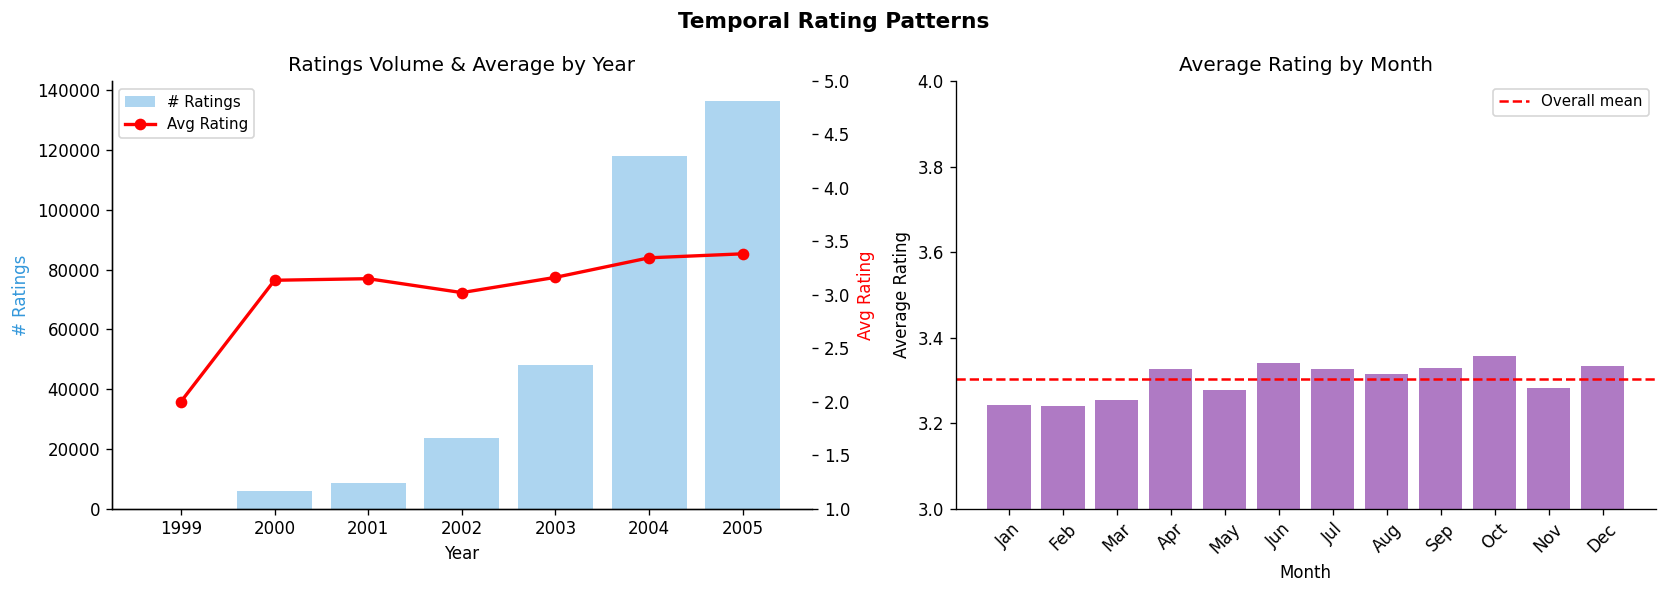

In [17]:
df_t = df.dropna(subset=['date']).copy()
df_t['year']    = df_t['date'].dt.year
df_t['month']   = df_t['date'].dt.month
df_t['weekday'] = df_t['date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Temporal Rating Patterns', fontsize=13, fontweight='bold')

# Average rating by year
year_stats = df_t.groupby('year')['rating'].agg(['mean', 'count']).reset_index()
ax = axes[0]
ax2 = ax.twinx()
ax.bar(year_stats['year'], year_stats['count'], alpha=0.4, color='#3498db', label='# Ratings')
ax2.plot(year_stats['year'], year_stats['mean'], 'ro-', linewidth=2, label='Avg Rating')
ax.set_xlabel('Year'); ax.set_ylabel('# Ratings', color='#3498db')
ax2.set_ylabel('Avg Rating', color='red')
ax2.set_ylim(1, 5)
ax.set_title('Ratings Volume & Average by Year')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Average rating by month
month_stats = df_t.groupby('month')['rating'].agg(['mean', 'count']).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax = axes[1]
ax.bar(month_stats['month'], month_stats['mean'], color='#9b59b6', alpha=0.8)
ax.axhline(df_t['rating'].mean(), color='red', linestyle='--', label='Overall mean')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names, rotation=45)
ax.set_xlabel('Month'); ax.set_ylabel('Average Rating')
ax.set_ylim(3.0, 4.0)
ax.set_title('Average Rating by Month')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing & Train/Test Split <a id='4-preprocessing'></a>

## 4.1  Temporal train / test split

In [18]:
print('Splitting data (temporal, per user) ...')
train_df, test_df = temporal_train_test_split(df, test_ratio=0.2)


train_users  = set(train_df['user_id'].unique())
train_movies = set(train_df['movie_id'].unique())

test_df_filtered = test_df[
    test_df['user_id'].isin(train_users) &
    test_df['movie_id'].isin(train_movies)
].copy()

filtered_out = len(test_df) - len(test_df_filtered)
print(f'  Removed {filtered_out:,} test entries not seen in training '
      f'(cold-start)')
print(f'  Final test set: {len(test_df_filtered):,} ratings')

test_df = test_df_filtered

Splitting data (temporal, per user) ...
✓  Train: 271,413 ratings (79.6%)  | Test: 69,356 ratings (20.4%)
  Removed 0 test entries not seen in training (cold-start)
  Final test set: 69,356 ratings


## 4.2  Split statistics

Train set:


,count,mean,std,min,25%,50%,75%,max
rating,271413.0000,3.2996,1.1537,1.0000,3.0000,3.0000,4.0000,5.0000



Test set:


,count,mean,std,min,25%,50%,75%,max
rating,69356.0000,3.3210,1.1155,1.0000,3.0000,3.0000,4.0000,5.0000


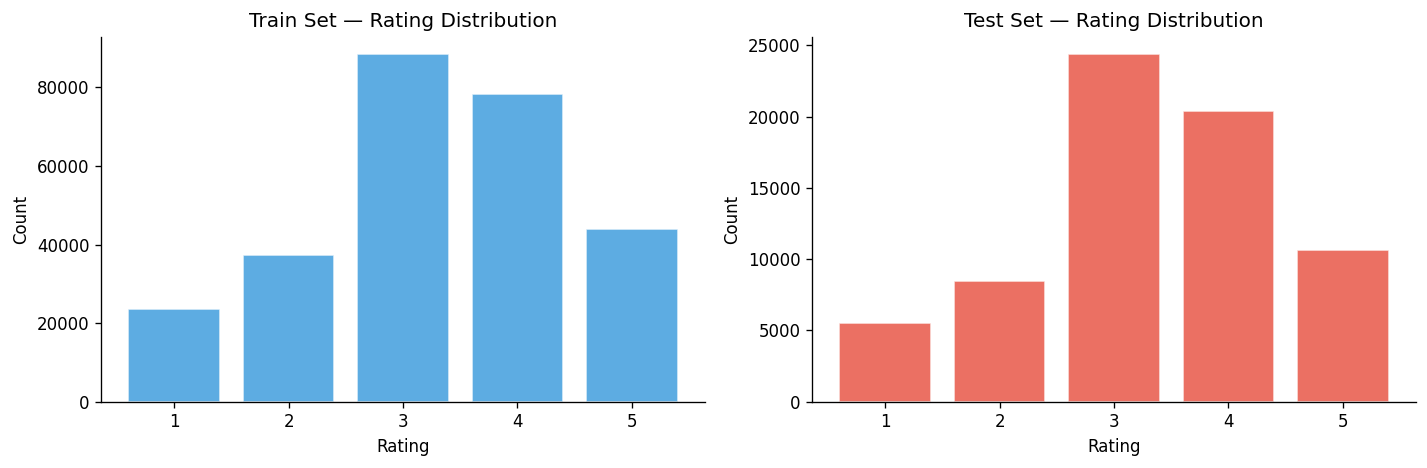

In [19]:
print('Train set:')
display(train_df['rating'].describe().to_frame().T)
print('\nTest set:')
display(test_df['rating'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (subset_df, label, color) in zip(
        axes,
        [(train_df, 'Train', '#3498db'), (test_df, 'Test', '#e74c3c')]):
    rc = subset_df['rating'].value_counts().sort_index()
    ax.bar(rc.index, rc.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{label} Set — Rating Distribution')
    ax.set_xlabel('Rating'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

## 5. Model 1: SVD — Matrix Factorisation <a id='5-svd'></a>

SVD decomposes the user–item rating matrix **R ≈ U Σ Vᵀ** into latent factor matrices.  
Predicted rating = global mean + user bias + item bias + **u⃗ᵤ · v⃗ᵢ**  
Optimised with SGD; handles sparsity well — core algorithm behind the Netflix Prize winner.

In [21]:
# ── Inline SVD model (mirrors src/models.py)
from sklearn.metrics.pairwise import cosine_similarity as _cosine_sim

class SVDRecommender:
    """Wrapper around scikit-surprise SVD."""

    def __init__(self, n_factors=100, n_epochs=20, lr_all=0.005,
                 reg_all=0.02, random_state=42):
        from surprise import SVD
        self.model = SVD(n_factors=n_factors, n_epochs=n_epochs,
                         lr_all=lr_all, reg_all=reg_all,
                         random_state=random_state, verbose=False)
        self._trainset = None
        self._all_movie_ids = None

    def fit(self, train_df: pd.DataFrame):
        from surprise import Dataset, Reader
        reader = Reader(rating_scale=(1, 5))
        data = Dataset.load_from_df(
            train_df[['user_id', 'movie_id', 'rating']], reader)
        self._trainset = data.build_full_trainset()
        self._all_movie_ids = set(train_df['movie_id'].unique())
        print('Training SVD ...', end=' ')
        self.model.fit(self._trainset)
        print('Done.')
        return self

    def predict(self, user_id: int, movie_id: int) -> float:
        return self.model.predict(user_id, movie_id).est

    def predict_batch(self, test_df: pd.DataFrame) -> np.ndarray:
        return np.array([self.predict(r.user_id, r.movie_id)
                         for r in tqdm(test_df.itertuples(), total=len(test_df),
                                       desc='SVD predict')])

    def recommend(self, user_id: int, train_df: pd.DataFrame,
                  top_k: int = 10, exclude_rated: bool = True) -> list:
        rated = set(train_df[train_df['user_id'] == user_id]['movie_id'])
        candidates = (self._all_movie_ids - rated) if exclude_rated else self._all_movie_ids
        scores = [(m, self.predict(user_id, m)) for m in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        return [m for m, _ in scores[:top_k]]

    def recommend_with_scores(self, user_id: int, train_df: pd.DataFrame,
                               top_k: int = 10) -> list:
        rated = set(train_df[train_df['user_id'] == user_id]['movie_id'])
        candidates = self._all_movie_ids - rated
        scores = [(m, self.predict(user_id, m)) for m in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:top_k]

print('✓ SVDRecommender defined')

✓ SVDRecommender defined


In [22]:
# Train SVD
t0 = time.time()
svd = SVDRecommender(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02)
svd.fit(train_df)
svd_train_time = time.time() - t0
print(f'SVD training time: {svd_train_time:.1f}s')

Training SVD ... Done.
SVD training time: 4.3s


## 5.1  Hyperparameter sensitivity: n_factors

  n_factors= 20 → RMSE=0.9019
  n_factors= 50 → RMSE=0.9033
  n_factors=100 → RMSE=0.9016
  n_factors=150 → RMSE=0.9028
  n_factors=200 → RMSE=0.9094

✓ Best n_factors = 100  (RMSE=0.9016)


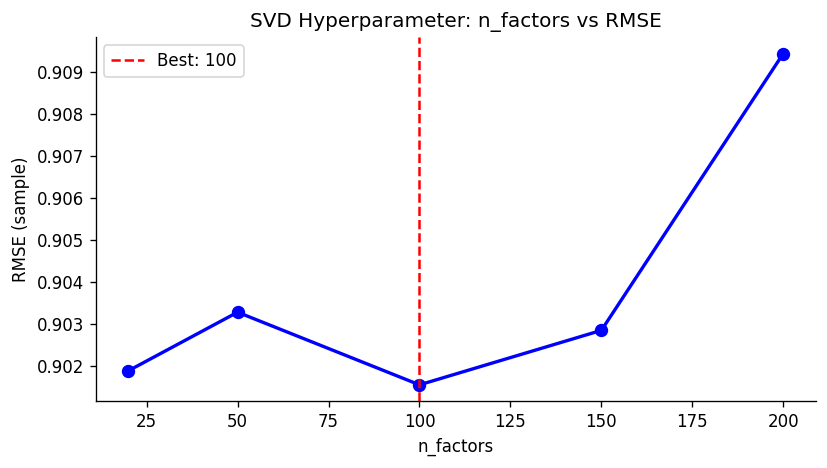

In [23]:
from surprise import SVD as SurpriseSVD, Dataset, Reader

reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(train_df[['user_id','movie_id','rating']], reader)
trainset_hp = surprise_data.build_full_trainset()


sample_test = test_df.sample(min(5000, len(test_df)), random_state=SEED)

factors_to_try = [20, 50, 100, 150, 200]
factor_rmses = []

for nf in factors_to_try:
    m = SurpriseSVD(n_factors=nf, n_epochs=15, random_state=SEED, verbose=False)
    m.fit(trainset_hp)
    preds = np.array([m.predict(r.user_id, r.movie_id).est
                      for r in sample_test.itertuples()])
    rmse = np.sqrt(np.mean((sample_test['rating'].values - preds)**2))
    factor_rmses.append(rmse)
    print(f'  n_factors={nf:>3d} → RMSE={rmse:.4f}')

best_nf = factors_to_try[np.argmin(factor_rmses)]
print(f'\n✓ Best n_factors = {best_nf}  (RMSE={min(factor_rmses):.4f})')

plt.figure(figsize=(7, 4))
plt.plot(factors_to_try, factor_rmses, 'bo-', linewidth=2, markersize=7)
plt.axvline(best_nf, color='red', linestyle='--', label=f'Best: {best_nf}')
plt.xlabel('n_factors'); plt.ylabel('RMSE (sample)')
plt.title('SVD Hyperparameter: n_factors vs RMSE')
plt.legend(); plt.tight_layout(); plt.show()

## 6. Model 2: Item-Based Collaborative Filtering <a id='6-itemcf'></a>

Builds a user–item rating matrix → computes **item-item cosine similarity** →
predicts unknown ratings as a weighted average over the most similar items the user has already rated.

## Inline Item-Based CF (mirrors src/models.py)

In [25]:
class ItemBasedCF:
    """Item-Based Collaborative Filtering with cosine similarity."""

    def __init__(self, n_similar: int = 50):
        self.n_similar = n_similar
        self.item_similarity = None
        self.user_item_matrix = None
        self.movie_ids = None; self.user_ids = None
        self.movie_idx = None; self.user_idx = None
        self.global_mean = 0.0

    def fit(self, train_df: pd.DataFrame):
        print('Building user-item matrix ...', end=' ')
        self.global_mean = train_df['rating'].mean()
        pivot = train_df.pivot_table(index='user_id', columns='movie_id', values='rating')
        self.user_item_matrix = pivot.fillna(0).values.astype(np.float32)
        self.movie_ids = np.array(pivot.columns)
        self.user_ids  = np.array(pivot.index)
        self.movie_idx = {m: i for i, m in enumerate(self.movie_ids)}
        self.user_idx  = {u: i for i, u in enumerate(self.user_ids)}
        print(f'({len(self.user_ids):,} × {len(self.movie_ids):,})')
        print('Computing item-item cosine similarity ...', end=' ')
        sim = _cosine_sim(self.user_item_matrix.T)
        np.fill_diagonal(sim, 0.0)
        self.item_similarity = sim
        print('Done.')
        return self

    def _uv(self, user_id: int) -> np.ndarray:
        if user_id not in self.user_idx:
            return np.zeros(len(self.movie_ids))
        return self.user_item_matrix[self.user_idx[user_id]]

    def predict(self, user_id: int, movie_id: int) -> float:
        if movie_id not in self.movie_idx:
            return self.global_mean
        col = self.movie_idx[movie_id]
        sims = self.item_similarity[col]
        uv   = self._uv(user_id)
        rated_mask = uv > 0
        if not rated_mask.any():
            return self.global_mean
        s = sims * rated_mask
        top_idx = np.argsort(s)[::-1][:self.n_similar]
        denom = np.abs(s[top_idx]).sum()
        if denom == 0:
            return self.global_mean
        return float(np.dot(s[top_idx], uv[top_idx]) / denom)

    def predict_batch(self, test_df: pd.DataFrame) -> np.ndarray:
        return np.array([self.predict(r.user_id, r.movie_id)
                         for r in tqdm(test_df.itertuples(), total=len(test_df),
                                       desc='ItemCF predict')])

    def recommend(self, user_id: int, top_k: int = 10) -> list:
        if user_id not in self.user_idx:
            rated_counts = (self.user_item_matrix > 0).sum(axis=0)
            return [self.movie_ids[c] for c in np.argsort(rated_counts)[::-1][:top_k]]
        uv = self._uv(user_id)
        rated_mask = uv > 0
        unrated = np.where(~rated_mask)[0]
        scores = []
        for col in unrated:
            sims = self.item_similarity[col]
            denom = np.dot(np.abs(sims), rated_mask)
            if denom == 0:
                scores.append((col, self.global_mean))
            else:
                scores.append((col, np.dot(sims * rated_mask, uv) / denom))
        scores.sort(key=lambda x: x[1], reverse=True)
        return [self.movie_ids[c] for c, _ in scores[:top_k]]

    def recommend_with_scores(self, user_id: int, top_k: int = 10) -> list:
        uv = self._uv(user_id)
        if user_id not in self.user_idx:
            return []
        rated_mask = uv > 0
        unrated = np.where(~rated_mask)[0]
        scores = []
        for col in unrated:
            sims = self.item_similarity[col]
            denom = np.dot(np.abs(sims), rated_mask)
            if denom == 0: continue
            scores.append((self.movie_ids[col], np.dot(sims * rated_mask, uv) / denom))
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:top_k]

    def get_similar_movies(self, movie_id: int, top_n: int = 10) -> list:
        if movie_id not in self.movie_idx: return []
        col  = self.movie_idx[movie_id]
        sims = self.item_similarity[col]
        top  = np.argsort(sims)[::-1][:top_n]
        return [(self.movie_ids[i], sims[i]) for i in top]

    def explain_recommendation(self, user_id, movie_id, movie_titles=None, top_n=3):
        if movie_id not in self.movie_idx or user_id not in self.user_idx:
            return 'Recommendation based on overall popularity.'
        col  = self.movie_idx[movie_id]
        uv   = self._uv(user_id)
        sims = self.item_similarity[col]
        combined = sims * (uv > 0)
        top_idx  = np.argsort(combined)[::-1][:top_n]
        tname = (movie_titles.get(movie_id, str(movie_id))
                 if movie_titles else str(movie_id))
        lines = [f"We recommend '{tname}' because you enjoyed:"]
        for idx in top_idx:
            if combined[idx] <= 0: break
            mid = self.movie_ids[idx]
            mname = (movie_titles.get(mid, str(mid)) if movie_titles else str(mid))
            lines.append(f"  • '{mname}'  (similarity: {sims[idx]:.3f}, "
                         f"your rating: {int(uv[idx])}/5)")
        return '\n'.join(lines) if len(lines) > 1 else 'Recommended based on viewing patterns.'

print('✓ ItemBasedCF defined')

✓ ItemBasedCF defined


Train Item-Based CF

In [26]:
t0 = time.time()
item_cf = ItemBasedCF(n_similar=50)
item_cf.fit(train_df)
cf_train_time = time.time() - t0
print(f'\nItem-CF training time: {cf_train_time:.1f}s')

Building user-item matrix ... (3,000 × 942)
Computing item-item cosine similarity ... Done.

Item-CF training time: 1.3s


## 6.1  Item-item similarity heatmap (top 30 movies)

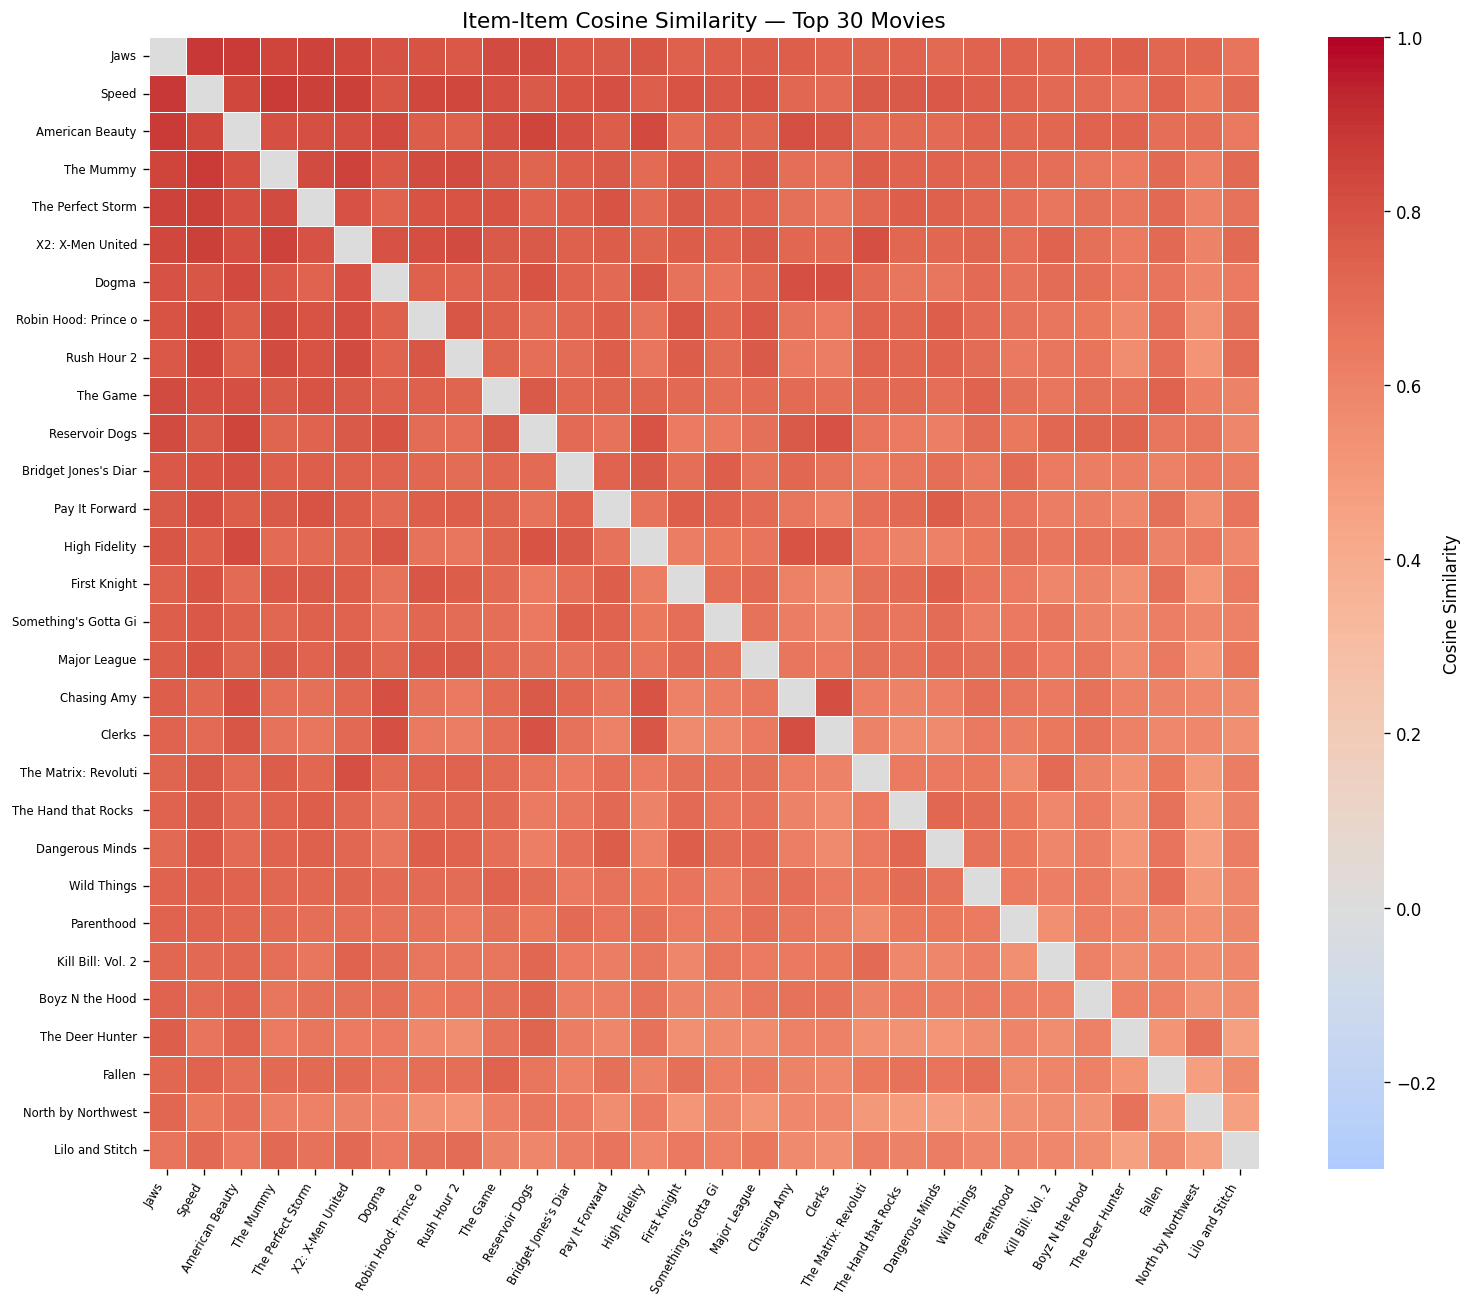

In [27]:
TOP_N_HEATMAP = 30
top_movie_cols = (
    train_df['movie_id'].value_counts().head(TOP_N_HEATMAP).index.tolist()
)
# Keeping only those that exist in the CF model
top_movie_cols = [m for m in top_movie_cols if m in item_cf.movie_idx]

indices = [item_cf.movie_idx[m] for m in top_movie_cols]
sim_sub = item_cf.item_similarity[np.ix_(indices, indices)]
labels  = [movie_titles.get(m, str(m))[:20] for m in top_movie_cols]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(sim_sub, xticklabels=labels, yticklabels=labels,
            cmap='coolwarm', center=0, vmin=-0.3, vmax=1,
            linewidths=0.3, annot=False, ax=ax,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title(f'Item-Item Cosine Similarity — Top {TOP_N_HEATMAP} Movies', fontsize=13)
plt.xticks(rotation=60, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('item_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Evaluation & Comparison <a id='7-evaluation'></a>

In [28]:
# ── Inline evaluation utilities (mirrors src/evaluation.py) ──────────────

def compute_rmse(actuals, predictions):
    return float(np.sqrt(np.mean((np.array(actuals) - np.array(predictions))**2)))

def compute_mae(actuals, predictions):
    return float(np.mean(np.abs(np.array(actuals) - np.array(predictions))))

def _ap_at_k(recommended, relevant, k=10):
    if not relevant: return 0.0
    top_k = recommended[:k]
    hits = running = 0.0
    for rank, item in enumerate(top_k, 1):
        if item in relevant:
            hits += 1; running += hits / rank
    return running / min(len(relevant), k)

def build_relevant(test_df, threshold=3.5):
    rel = defaultdict(set)
    for r in test_df.itertuples():
        if r.rating >= threshold:
            rel[r.user_id].add(r.movie_id)
    return rel

def compute_map_at_k(recs, test_df, k=10, threshold=3.5):
    rel = build_relevant(test_df, threshold)
    aps = [_ap_at_k(recs[u], rel[u], k) for u in recs if u in rel]
    return float(np.mean(aps)) if aps else 0.0

def compute_precision_at_k(recs, test_df, k=10, threshold=3.5):
    rel = build_relevant(test_df, threshold)
    ps = [sum(1 for m in recs[u][:k] if m in rel[u]) / k
          for u in recs if u in rel]
    return float(np.mean(ps)) if ps else 0.0

def compute_recall_at_k(recs, test_df, k=10, threshold=3.5):
    rel = build_relevant(test_df, threshold)
    rs = [sum(1 for m in recs[u][:k] if m in rel[u]) / len(rel[u])
          for u in recs if u in rel and rel[u]]
    return float(np.mean(rs)) if rs else 0.0

def compute_ndcg_at_k(recs, test_df, k=10, threshold=3.5):
    rel = build_relevant(test_df, threshold)
    scores = []
    for u, rec in recs.items():
        if u not in rel: continue
        dcg  = sum(1/np.log2(i+2) for i, m in enumerate(rec[:k]) if m in rel[u])
        idcg = sum(1/np.log2(i+2) for i in range(min(len(rel[u]), k)))
        scores.append(dcg/idcg if idcg > 0 else 0.0)
    return float(np.mean(scores)) if scores else 0.0

def compute_hit_rate(recs, test_df, k=10, threshold=3.5):
    rel = build_relevant(test_df, threshold)
    hits = total = 0
    for u, rec in recs.items():
        if u not in rel: continue
        total += 1
        if any(m in rel[u] for m in rec[:k]):
            hits += 1
    return hits / total if total > 0 else 0.0

def compute_coverage(recs, all_movies):
    rec_movies = {m for rec in recs.values() for m in rec}
    return len(rec_movies) / len(all_movies) if all_movies else 0.0

def full_evaluation(name, test_df, preds, recs, all_movies, k=10, threshold=3.5):
    actuals = test_df['rating'].values
    preds_c = np.clip(preds, 1, 5)
    res = {
        'model': name,
        'rmse': compute_rmse(actuals, preds_c),
        'mae':  compute_mae(actuals, preds_c),
        'map@10': compute_map_at_k(recs, test_df, k, threshold),
        'precision@10': compute_precision_at_k(recs, test_df, k, threshold),
        'recall@10': compute_recall_at_k(recs, test_df, k, threshold),
        'ndcg@10': compute_ndcg_at_k(recs, test_df, k, threshold),
        'hit_rate@10': compute_hit_rate(recs, test_df, k, threshold),
        'coverage': compute_coverage(recs, all_movies),
    }
    print(f"\n{'='*55}")
    print(f"  Evaluation Results — {name}")
    print(f"{'='*55}")
    print(f"  RMSE          : {res['rmse']:.4f}")
    print(f"  MAE           : {res['mae']:.4f}")
    print(f"  MAP@10        : {res['map@10']:.4f}   ← PRIMARY RANKING METRIC")
    print(f"  Precision@10  : {res['precision@10']:.4f}")
    print(f"  Recall@10     : {res['recall@10']:.4f}")
    print(f"  NDCG@10       : {res['ndcg@10']:.4f}")
    print(f"  Hit Rate@10   : {res['hit_rate@10']:.4f}")
    print(f"  Coverage      : {res['coverage']:.4f}")
    print(f"{'='*55}")
    return res

print('✓ Evaluation utilities defined')

✓ Evaluation utilities defined


Generating recommendations for all test users

In [29]:
TOP_K = 10
all_movie_ids = set(train_df['movie_id'].unique())
test_users    = test_df['user_id'].unique().tolist()

print(f'Generating Top-{TOP_K} recommendations for {len(test_users):,} users...')

# SVD recommendations
t0 = time.time()
svd_recs = {}
for uid in tqdm(test_users, desc='SVD recs'):
    svd_recs[uid] = svd.recommend(uid, train_df, top_k=TOP_K)
svd_rec_time = time.time() - t0

# Item-CF recommendations
t0 = time.time()
cf_recs = {}
for uid in tqdm(test_users, desc='ItemCF recs'):
    cf_recs[uid] = item_cf.recommend(uid, top_k=TOP_K)
cf_rec_time = time.time() - t0

print(f'\nSVD   recommendation time: {svd_rec_time:.1f}s')
print(f'ItemCF recommendation time: {cf_rec_time:.1f}s')

Generating Top-10 recommendations for 3,000 users...


SVD recs:   0%|          | 0/3000 [00:00<?, ?it/s]

ItemCF recs:   0%|          | 0/3000 [00:00<?, ?it/s]


SVD   recommendation time: 22.2s
ItemCF recommendation time: 36.8s


Batch predictions on test set

In [30]:
print('Computing rating predictions on test set...')
svd_preds = svd.predict_batch(test_df)
cf_preds  = item_cf.predict_batch(test_df)

Computing rating predictions on test set...


SVD predict:   0%|          | 0/69356 [00:00<?, ?it/s]

ItemCF predict:   0%|          | 0/69356 [00:00<?, ?it/s]

Full evaluation

In [31]:
svd_results = full_evaluation('SVD', test_df, svd_preds, svd_recs,
                               all_movie_ids, k=TOP_K)
cf_results  = full_evaluation('Item-Based CF', test_df, cf_preds, cf_recs,
                               all_movie_ids, k=TOP_K)

# Add timing info
svd_results['train_time_s'] = svd_train_time
cf_results['train_time_s']  = cf_train_time

results_df = pd.DataFrame([svd_results, cf_results]).set_index('model')
print('\n  Comparison Table:')
display(results_df)


  Evaluation Results — SVD
  RMSE          : 0.9023
  MAE           : 0.6978
  MAP@10        : 0.0677   ← PRIMARY RANKING METRIC
  Precision@10  : 0.1125
  Recall@10     : 0.1212
  NDCG@10       : 0.1449
  Hit Rate@10   : 0.6497
  Coverage      : 0.3514

  Evaluation Results — Item-Based CF
  RMSE          : 0.9614
  MAE           : 0.7532
  MAP@10        : 0.0161   ← PRIMARY RANKING METRIC
  Precision@10  : 0.0471
  Recall@10     : 0.0450
  NDCG@10       : 0.0452
  Hit Rate@10   : 0.3113
  Coverage      : 0.7962

  Comparison Table:


,rmse,mae,map@10,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,train_time_s
model,,,,,,,,,
SVD,0.9023,0.6978,0.0677,0.1125,0.1212,0.1449,0.6497,0.3514,4.3106
Item-Based CF,0.9614,0.7532,0.0161,0.0471,0.0450,0.0452,0.3113,0.7962,1.3401


## 7.1  Comparison plots

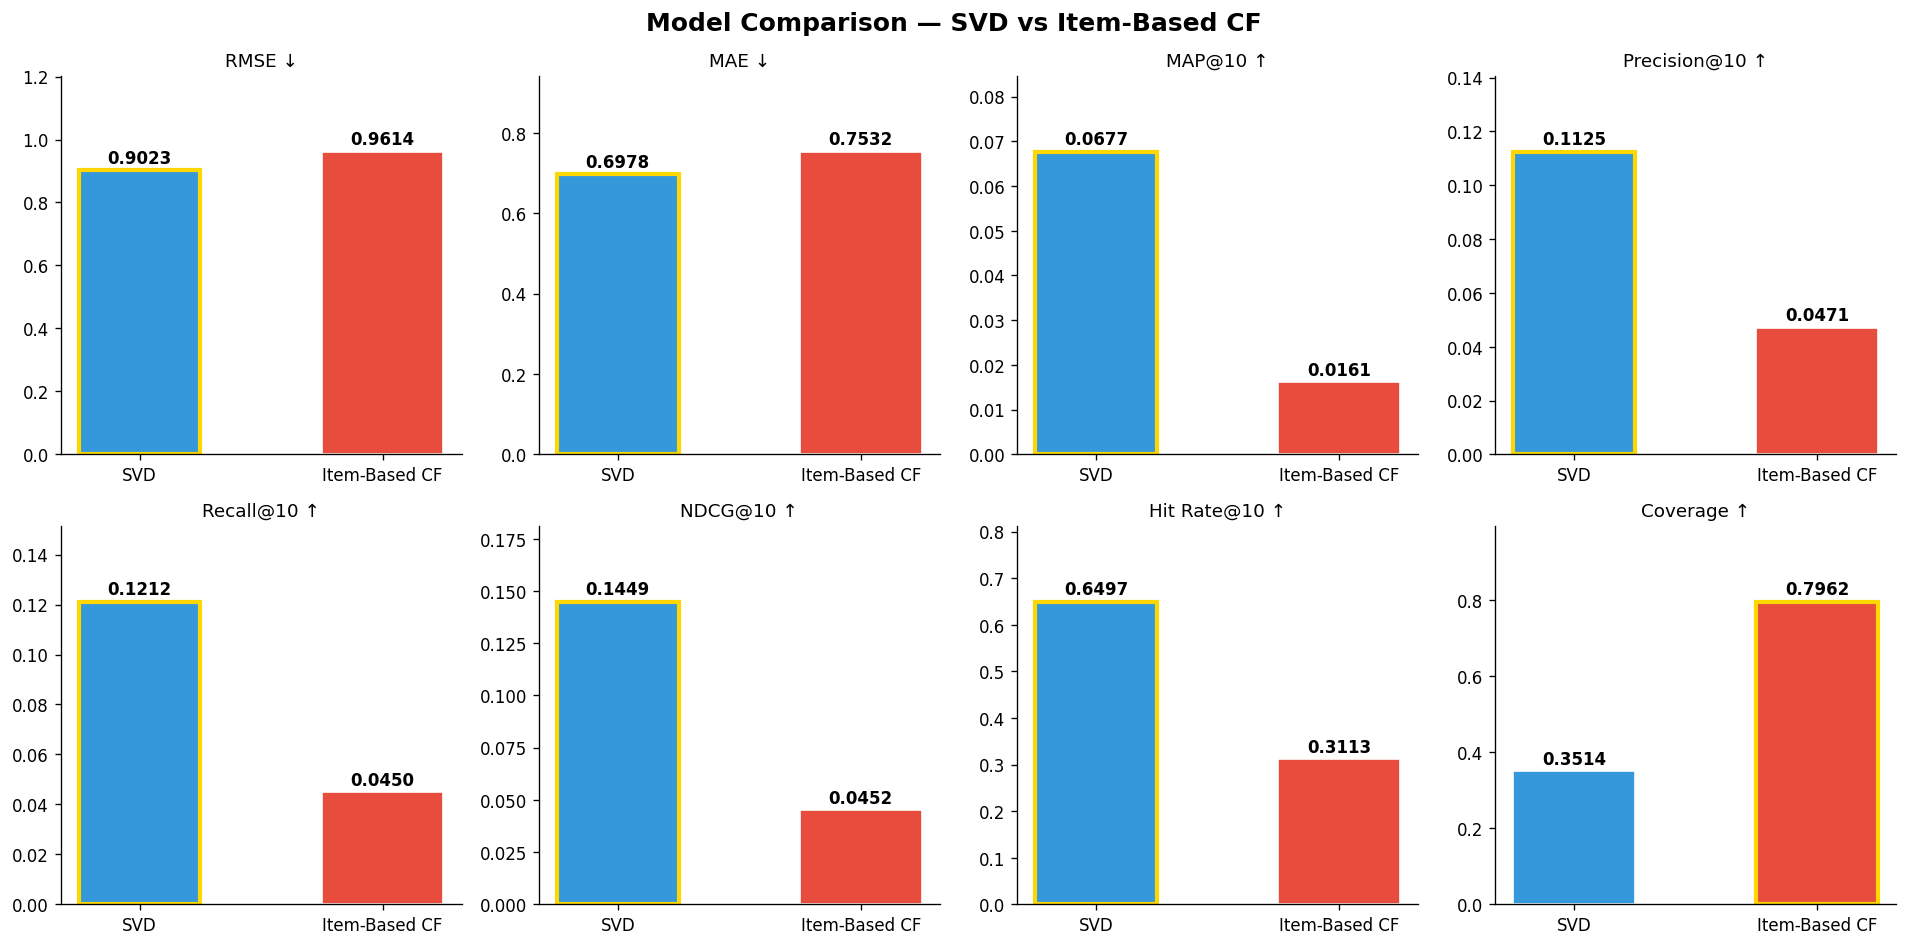

✓ Comparison plot saved to model_comparison.png


In [32]:
metrics = ['rmse', 'mae', 'map@10', 'precision@10',
           'recall@10', 'ndcg@10', 'hit_rate@10', 'coverage']
labels  = ['RMSE ↓', 'MAE ↓', 'MAP@10 ↑', 'Precision@10 ↑',
           'Recall@10 ↑', 'NDCG@10 ↑', 'Hit Rate@10 ↑', 'Coverage ↑']
n_cols, n_rows = 4, 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
fig.suptitle('Model Comparison — SVD vs Item-Based CF', fontsize=15, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#e74c3c']
model_names = ['SVD', 'Item-Based CF']

for ax, metric, label in zip(axes, metrics, labels):
    vals = [svd_results[metric], cf_results[metric]]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.25 + 1e-6)
    best_idx = np.argmin(vals) if '↓' in label else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Comparison plot saved to model_comparison.png')

## 7.2  Predicted vs actual rating distributions

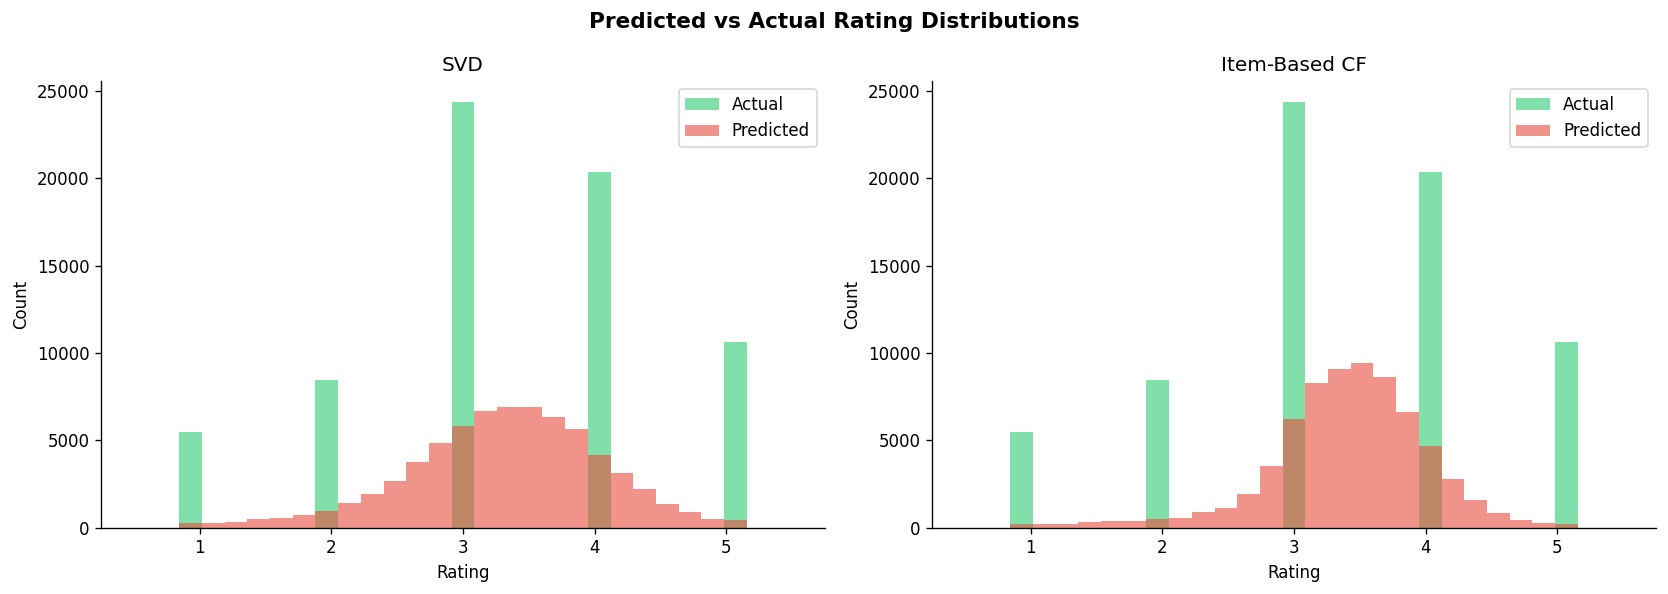

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted vs Actual Rating Distributions', fontsize=13, fontweight='bold')

for ax, (preds, name) in zip(axes, [(svd_preds, 'SVD'), (cf_preds, 'Item-Based CF')]):
    bins = np.linspace(0.5, 5.5, 30)
    ax.hist(test_df['rating'].values, bins=bins, alpha=0.6, label='Actual', color='#2ecc71')
    ax.hist(np.clip(preds, 1, 5), bins=bins, alpha=0.6, label='Predicted', color='#e74c3c')
    ax.set_xlabel('Rating'); ax.set_ylabel('Count')
    ax.set_title(name); ax.legend()

plt.tight_layout(); plt.show()

## 7.3  Residual / error distribution

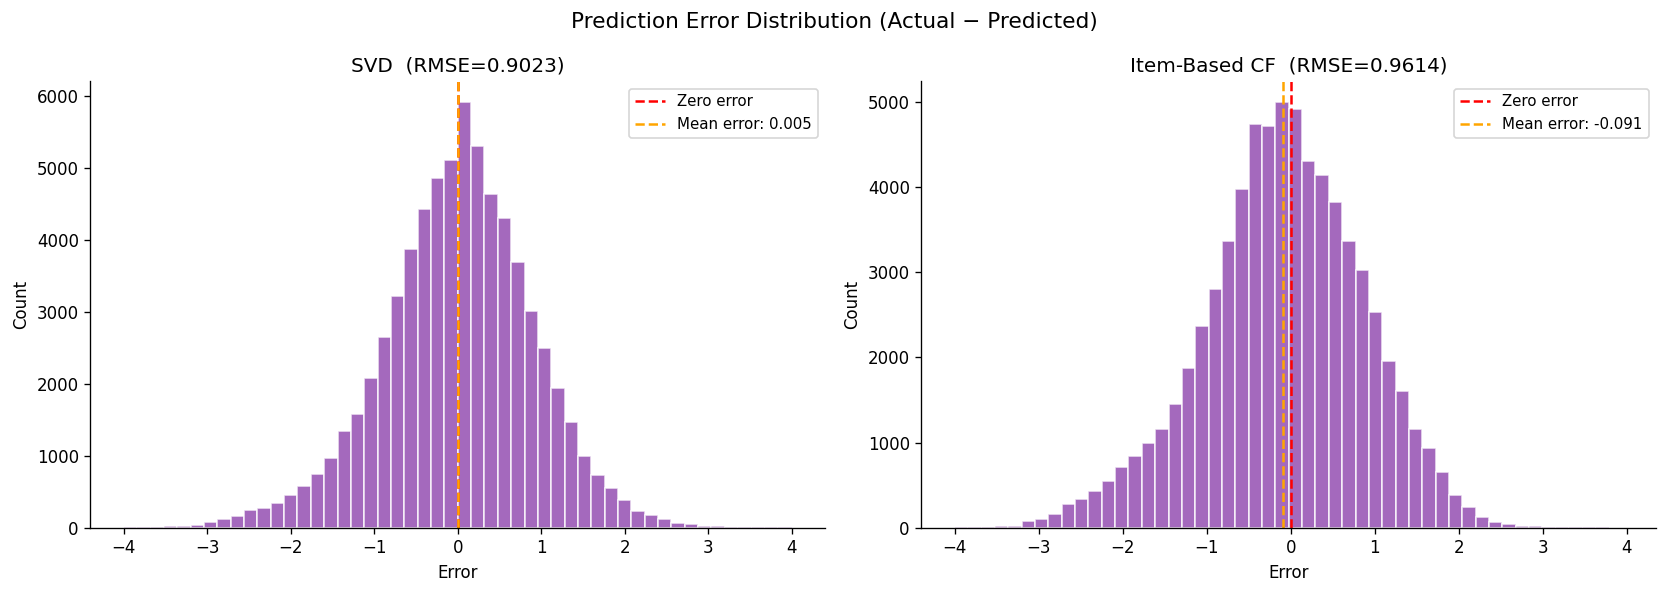

In [34]:
actuals = test_df['rating'].values
svd_errors = actuals - np.clip(svd_preds, 1, 5)
cf_errors  = actuals - np.clip(cf_preds,  1, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction Error Distribution (Actual − Predicted)', fontsize=13)

for ax, (errs, name) in zip(axes, [(svd_errors, 'SVD'), (cf_errors, 'Item-Based CF')]):
    ax.hist(errs, bins=50, color='#8e44ad', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(errs.mean(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Mean error: {errs.mean():.3f}')
    ax.set_xlabel('Error'); ax.set_ylabel('Count')
    ax.set_title(f'{name}  (RMSE={compute_rmse(actuals, np.clip([p for p in (svd_preds if name=="SVD" else cf_preds)], 1, 5)):.4f})')
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

## 8. Top-K Recommendation Generation <a id='8-recommendations'></a>

8.1  Pretty-print recommendations for sample users

In [35]:
SAMPLE_DISPLAY_USERS = test_users[:5]

for uid in SAMPLE_DISPLAY_USERS:
    print(f"\n{'='*65}")
    print(f"  Recommendations for User {uid}")
    print(f"{'='*65}")

    # Past ratings
    history = (train_df[train_df['user_id'] == uid]
               .sort_values('rating', ascending=False).head(5))
    print("\n  📽  Top-5 past ratings:")
    for row in history.itertuples():
        title = movie_titles.get(row.movie_id, str(row.movie_id))
        stars = '★' * int(row.rating) + '☆' * (5 - int(row.rating))
        print(f"     {stars}  {title[:40]}")

    # SVD recs
    print(f"\n  🤖  SVD Top-{TOP_K} recommendations:")
    for rank, mid in enumerate(svd_recs.get(uid, [])[:TOP_K], 1):
        pred = svd.predict(uid, mid)
        title = movie_titles.get(mid, str(mid))
        print(f"     {rank:2d}. {title[:40]:<40}  (predicted: {pred:.2f}/5)")

    # Item-CF recs
    print(f"\n  🎯  Item-CF Top-{TOP_K} recommendations:")
    for rank, mid in enumerate(cf_recs.get(uid, [])[:TOP_K], 1):
        pred = item_cf.predict(uid, mid)
        title = movie_titles.get(mid, str(mid))
        print(f"     {rank:2d}. {title[:40]:<40}  (predicted: {pred:.2f}/5)")

print(f"\n{'='*65}")


  Recommendations for User 1333

  📽  Top-5 past ratings:
     ★★★★★  Magnolia: Bonus Material
     ★★★★★  House of Sand and Fog
     ★★★★☆  Tuck Everlasting
     ★★★★☆  Jaws
     ★★★★☆  American Beauty

  🤖  SVD Top-10 recommendations:
      1. Seven Samurai                             (predicted: 4.11/5)
      2. Christmas with The Simpsons               (predicted: 3.94/5)
      3. Animal Crackers                           (predicted: 3.88/5)
      4. Bill Cosby: Himself                       (predicted: 3.87/5)
      5. A Night at the Opera                      (predicted: 3.86/5)
      6. When Dinosaurs Roamed America             (predicted: 3.82/5)
      7. Futurama: Monster Robot Maniac Fun Colle  (predicted: 3.81/5)
      8. Absolutely Fabulous: Series 5             (predicted: 3.81/5)
      9. City Lights                               (predicted: 3.81/5)
     10. George Carlin: What Am I Doing in New Je  (predicted: 3.78/5)

  🎯  Item-CF Top-10 recommendations:
      1. IFilm

## 8.2  Recommendation overlap between models

Recommendation Overlap (Jaccard @ 10):
  Mean    : 0.0262
  Median  : 0.0000
  Max     : 0.2500


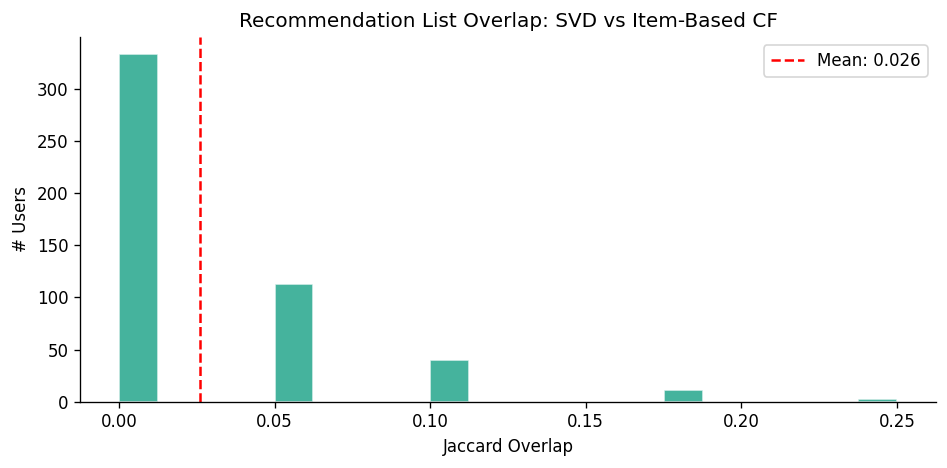

In [36]:
overlaps = []
for uid in test_users[:500]:
    s = set(svd_recs.get(uid, [])[:TOP_K])
    c = set(cf_recs.get(uid,  [])[:TOP_K])
    if s and c:
        overlaps.append(len(s & c) / len(s | c))

print(f'Recommendation Overlap (Jaccard @ {TOP_K}):')
print(f'  Mean    : {np.mean(overlaps):.4f}')
print(f'  Median  : {np.median(overlaps):.4f}')
print(f'  Max     : {np.max(overlaps):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(overlaps, bins=20, color='#16a085', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(overlaps), color='red', linestyle='--',
           label=f'Mean: {np.mean(overlaps):.3f}')
ax.set_xlabel('Jaccard Overlap'); ax.set_ylabel('# Users')
ax.set_title('Recommendation List Overlap: SVD vs Item-Based CF')
ax.legend(); plt.tight_layout(); plt.show()

## 9. Explainability <a id='9-explainability'></a>

## 9.1  Item-CF explanation (interpretable by design)

In [37]:
print('=' * 65)
print('  Item-Based CF — Recommendation Explanations')
print('=' * 65)

for uid in test_users[:3]:
    rec_list = cf_recs.get(uid, [])
    if not rec_list:
        continue
    top_movie = rec_list[0]
    explanation = item_cf.explain_recommendation(
        uid, top_movie, movie_titles=movie_titles, top_n=3
    )
    print(f'\n[User {uid}]')
    print(explanation)

print('\n' + '=' * 65)

  Item-Based CF — Recommendation Explanations

[User 1333]
We recommend 'IFilm: Deranged' because you enjoyed:
  • 'The Isle'  (similarity: 0.046, your rating: 3/5)
  • 'Henry Fool'  (similarity: 0.025, your rating: 4/5)
  • 'What the #$*! Do We Know!?'  (similarity: 0.024, your rating: 3/5)

[User 2213]
We recommend 'Dave Chappelle: For What It's Worth' because you enjoyed:
  • 'Pooh's Heffalump Movie'  (similarity: 0.098, your rating: 5/5)
  • 'Back to the Future Part III'  (similarity: 0.087, your rating: 5/5)
  • 'Robin Hood: Prince of Thieves'  (similarity: 0.076, your rating: 5/5)

[User 3321]
We recommend 'Monster-in-Law: Bonus Material' because you enjoyed:
  • 'Homicide: Life on the Street: Season 7'  (similarity: 0.146, your rating: 3/5)
  • 'The Rise and Fall of ECW'  (similarity: 0.144, your rating: 4/5)
  • 'Batman the Animated Series: Vol. 3'  (similarity: 0.103, your rating: 4/5)



## 9.2  SVD explanation (neighbourhood-based proxy)

In [38]:
def explain_svd_recommendation(uid, movie_id, svd_model, train_df,
                                movie_titles=None, n_seed=3):
    target = (movie_titles or {}).get(movie_id, str(movie_id))
    history = (train_df[train_df['user_id'] == uid]
               .sort_values('rating', ascending=False).head(n_seed))
    if history.empty:
        return f"Recommended '{target}' based on popular titles."
    pred = svd_model.predict(uid, movie_id)
    lines = [
        f"We recommend '{target}' (predicted rating: {pred:.1f}/5)",
        "Users who enjoyed the following also rated it highly:",
    ]
    for row in history.itertuples():
        t = (movie_titles or {}).get(row.movie_id, str(row.movie_id))
        lines.append(f"  • '{t}'  (your rating: {int(row.rating)}/5)")
    return '\n'.join(lines)


print('=' * 65)
print('  SVD — Recommendation Explanations (neighbourhood proxy)')
print('=' * 65)

for uid in test_users[:3]:
    rec_list = svd_recs.get(uid, [])
    if not rec_list:
        continue
    explanation = explain_svd_recommendation(
        uid, rec_list[0], svd, train_df, movie_titles, n_seed=3
    )
    print(f'\n[User {uid}]')
    print(explanation)

print('\n' + '=' * 65)

  SVD — Recommendation Explanations (neighbourhood proxy)

[User 1333]
We recommend 'Seven Samurai' (predicted rating: 4.1/5)
Users who enjoyed the following also rated it highly:
  • 'Magnolia: Bonus Material'  (your rating: 5/5)
  • 'House of Sand and Fog'  (your rating: 5/5)
  • 'Tuck Everlasting'  (your rating: 4/5)

[User 2213]
We recommend 'Ray' (predicted rating: 4.7/5)
Users who enjoyed the following also rated it highly:
  • 'First Knight'  (your rating: 5/5)
  • 'The Mighty'  (your rating: 5/5)
  • 'The Matrix: Revolutions'  (your rating: 5/5)

[User 3321]
We recommend 'Glory: Bonus Material' (predicted rating: 3.7/5)
Users who enjoyed the following also rated it highly:
  • 'The Deer Hunter'  (your rating: 5/5)
  • 'Something's Gotta Give'  (your rating: 5/5)
  • 'Ray'  (your rating: 5/5)



## 9.3  Similar movies exploration

In [39]:
# Pick the 3 most-rated movies and show their top-5 similar movies
top3_movies = train_df['movie_id'].value_counts().head(3).index.tolist()

print('Most similar movies (Item-CF cosine similarity)\n')
for mid in top3_movies:
    title = movie_titles.get(mid, str(mid))
    similars = item_cf.get_similar_movies(mid, top_n=5)
    print(f'  🎬 {title} (id={mid})')
    for sim_mid, sim_score in similars:
        sim_title = movie_titles.get(sim_mid, str(sim_mid))
        print(f'     → {sim_title:<35}  similarity={sim_score:.4f}')
    print()

Most similar movies (Item-CF cosine similarity)

  🎬 Jaws (id=798)
     → Speed                                similarity=0.8833
     → American Beauty                      similarity=0.8773
     → The Perfect Storm                    similarity=0.8508
     → The Mummy                            similarity=0.8445
     → X2: X-Men United                     similarity=0.8399

  🎬 Speed (id=607)
     → Jaws                                 similarity=0.8833
     → The Mummy                            similarity=0.8789
     → X2: X-Men United                     similarity=0.8622
     → The Perfect Storm                    similarity=0.8620
     → American Beauty                      similarity=0.8405

  🎬 American Beauty (id=571)
     → Jaws                                 similarity=0.8773
     → Reservoir Dogs                       similarity=0.8438
     → Speed                                similarity=0.8405
     → Dogma                                similarity=0.8312
     → High Fid

## 10. Qualitative Analysis — Success, Failure & Cold-Start Cases <a id='10-analysis'></a>

## 10.1  Categorise users by recommendation quality

In [40]:
RELEVANCE_THRESHOLD = 3.5

def analyse_quality(recs, test_df, train_df, movie_titles=None,
                    threshold=3.5, k=10, n_examples=3, model_name=''):
    rel = build_relevant(test_df, threshold)
    successes, failures, cold_starts = [], [], []
    hit_counts = {}

    for uid, rec in recs.items():
        if uid not in rel: continue
        n_train = (train_df['user_id'] == uid).sum()
        hits = sum(1 for m in rec[:k] if m in rel[uid])
        hit_counts[uid] = hits
        if n_train < 5:
            cold_starts.append(uid)
        elif hits >= 2:
            successes.append(uid)
        elif hits == 0:
            failures.append(uid)

    print(f"\n{'='*65}")
    print(f"  Qualitative Analysis — {model_name}")
    print(f"{'='*65}")
    print(f"  Success  (≥2 hits in top-{k})  : {len(successes):,}")
    print(f"  Failure  (0 hits in top-{k})   : {len(failures):,}")
    print(f"  Cold-Start (<5 train ratings)   : {len(cold_starts):,}")
    print(f"  Avg hits@{k}                    : {np.mean(list(hit_counts.values())):.2f}")

    def _print_examples(ulist, label, n):
        print(f"\n  {label}")
        for uid in ulist[:n]:
            rec = recs.get(uid, [])[:k]
            n_train = (train_df['user_id'] == uid).sum()
            rel_titles = [movie_titles.get(m, str(m))
                          if movie_titles else str(m)
                          for m in list(rel[uid])[:3]]
            rec_titles = [movie_titles.get(m, str(m))
                          if movie_titles else str(m)
                          for m in rec[:3]]
            print(f"\n  User {uid}  (train={n_train}, hits@{k}={hit_counts.get(uid,0)})")
            print(f"    Relevant in test  : {', '.join(rel_titles)}")
            print(f"    Top-3 recs        : {', '.join(rec_titles)}")

    _print_examples(successes,  '✅  Success Cases',    n_examples)
    _print_examples(failures,   '❌  Failure Cases',    n_examples)
    _print_examples(cold_starts,'🔍  Cold-Start Cases', n_examples)

    return {
        'n_success': len(successes), 'n_failure': len(failures),
        'n_cold_start': len(cold_starts),
        'avg_hits': np.mean(list(hit_counts.values())) if hit_counts else 0,
    }


svd_quality = analyse_quality(svd_recs, test_df, train_df, movie_titles,
                               model_name='SVD', n_examples=3)
cf_quality  = analyse_quality(cf_recs,  test_df, train_df, movie_titles,
                               model_name='Item-Based CF', n_examples=3)


  Qualitative Analysis — SVD
  Success  (≥2 hits in top-10)  : 912
  Failure  (0 hits in top-10)   : 1,035
  Cold-Start (<5 train ratings)   : 0
  Avg hits@10                    : 1.12

  ✅  Success Cases

  User 1333  (train=124, hits@10=2)
    Relevant in test  : The Star Maker, The Prime of Miss Jean Brodie, Seven Samurai
    Top-3 recs        : Seven Samurai, Christmas with The Simpsons, Animal Crackers

  User 3458  (train=68, hits@10=2)
    Relevant in test  : Journeys with George, The Big Clock, Eyes Without a Face
    Top-3 recs        : Yojimbo, The Wire: Season 1, Animal Crackers

  User 6206  (train=76, hits@10=2)
    Relevant in test  : Bride and Prejudice, Dear Frankie, Herbie Rides Again
    Top-3 recs        : Seven Samurai, Futurama: Monster Robot Maniac Fun Collection, George Carlin: Personal Favorites

  ❌  Failure Cases

  User 3998  (train=94, hits@10=0)
    Relevant in test  : Dear Frankie, Herbie Rides Again, Touched by an Angel: Season 1
    Top-3 recs        : 

## 10.2  Quality comparison plot

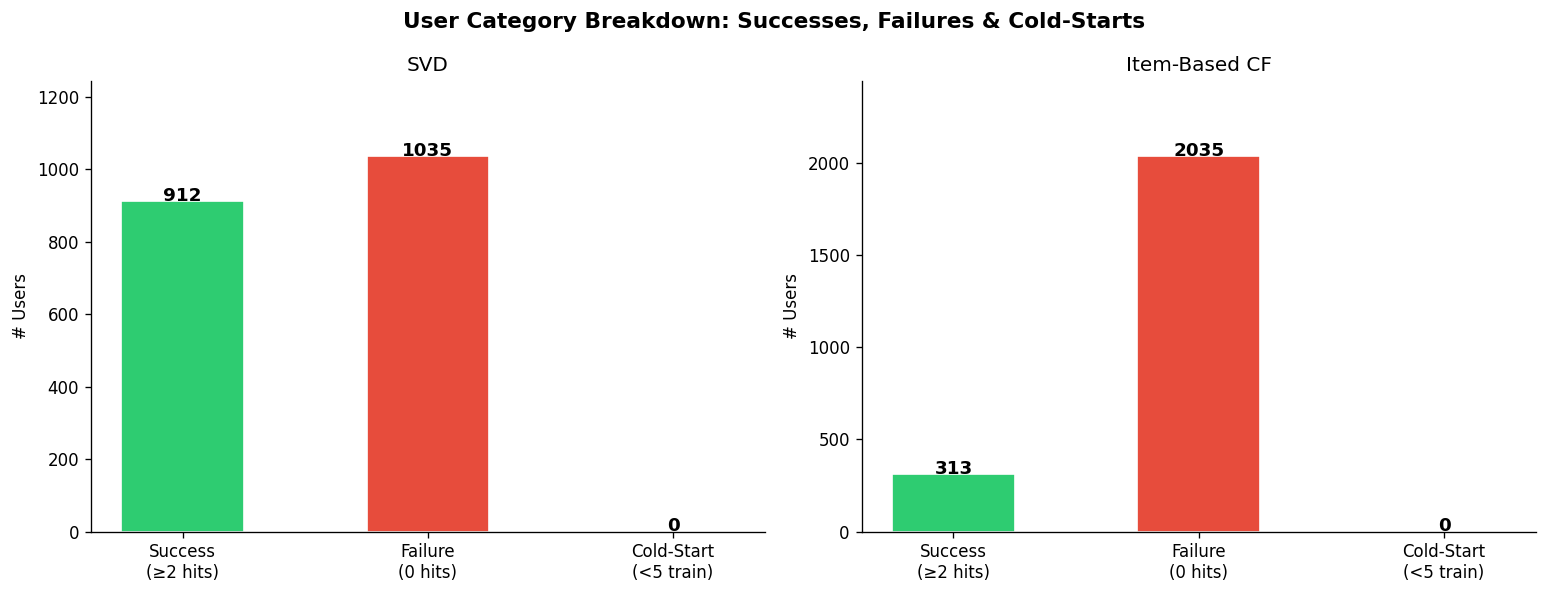

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('User Category Breakdown: Successes, Failures & Cold-Starts',
             fontsize=13, fontweight='bold')

for ax, (quality, name) in zip(axes,
        [(svd_quality, 'SVD'), (cf_quality, 'Item-Based CF')]):
    categories = ['Success\n(≥2 hits)', 'Failure\n(0 hits)', 'Cold-Start\n(<5 train)']
    values = [quality['n_success'], quality['n_failure'], quality['n_cold_start']]
    colors_cat = ['#2ecc71', '#e74c3c', '#f39c12']
    bars = ax.bar(categories, values, color=colors_cat, edgecolor='white', width=0.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(v), ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('# Users'); ax.set_title(name)
    ax.set_ylim(0, max(values) * 1.2 + 1)

plt.tight_layout(); plt.show()

## 10.3  Hits@K distribution

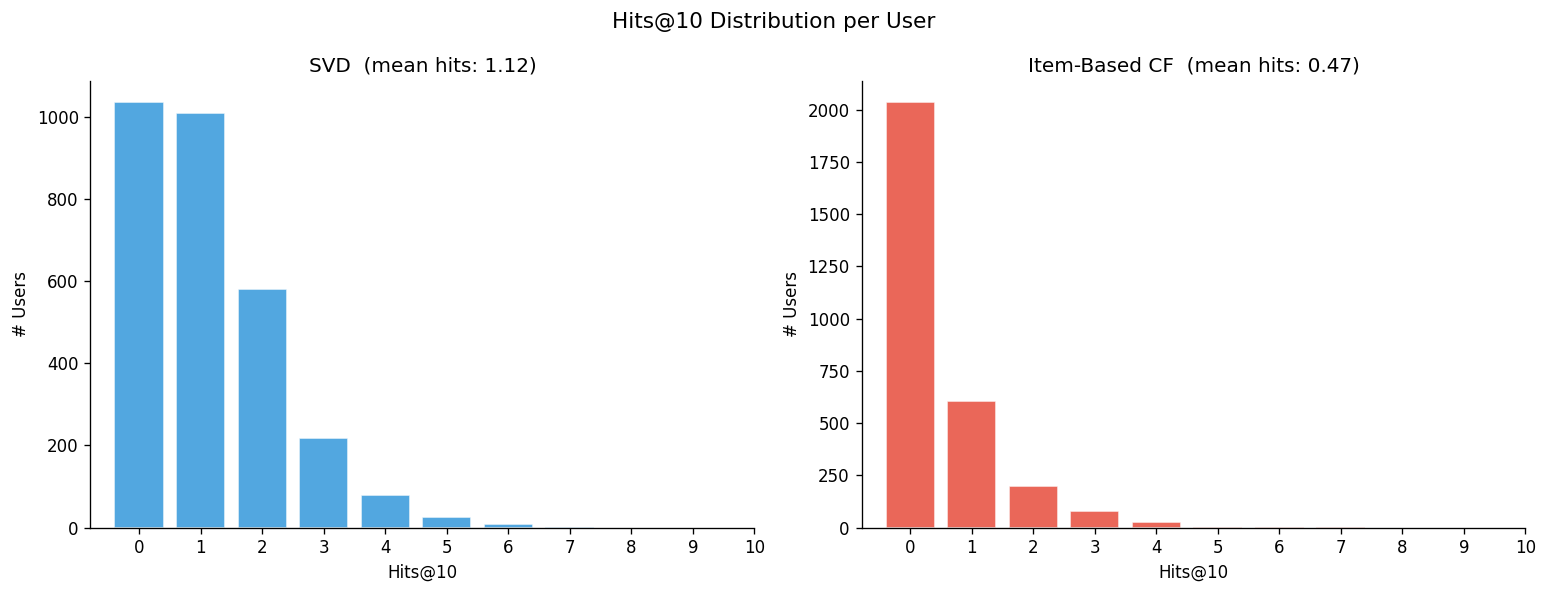

In [42]:
rel = build_relevant(test_df, RELEVANCE_THRESHOLD)

svd_hits_dist = [sum(1 for m in svd_recs.get(u, [])[:TOP_K] if m in rel[u])
                 for u in test_users if u in rel]
cf_hits_dist  = [sum(1 for m in cf_recs.get(u,  [])[:TOP_K] if m in rel[u])
                 for u in test_users if u in rel]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Hits@{TOP_K} Distribution per User', fontsize=13)

for ax, (hits, name, color) in zip(axes,
        [(svd_hits_dist, 'SVD', '#3498db'),
         (cf_hits_dist,  'Item-Based CF', '#e74c3c')]):
    counts = pd.Series(hits).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel(f'Hits@{TOP_K}'); ax.set_ylabel('# Users')
    ax.set_title(f'{name}  (mean hits: {np.mean(hits):.2f})')
    ax.set_xticks(range(TOP_K + 1))

plt.tight_layout(); plt.show()

## 11. Summary & Conclusions <a id='11-summary'></a>

## Final comparison table

In [43]:
summary = results_df[['rmse', 'mae', 'map@10', 'precision@10',
                       'recall@10', 'ndcg@10', 'hit_rate@10', 'coverage',
                       'train_time_s']].copy()
summary.index.name = 'Model'

def highlight_best(s):
    """Highlight the best value in each column (green)."""
    lower_is_better = s.name in ['rmse', 'mae', 'train_time_s']
    best_idx = s.idxmin() if lower_is_better else s.idxmax()
    return ['background-color: #d5f5e3; font-weight: bold'
            if idx == best_idx else '' for idx in s.index]

print('\n  Final Evaluation Summary')
display(summary.style.apply(highlight_best))


  Final Evaluation Summary


,rmse,mae,map@10,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,train_time_s
Model,,,,,,,,,
SVD,0.902340,0.697751,0.067686,0.112487,0.121163,0.144908,0.649746,0.351380,4.310623
Item-Based CF,0.961436,0.753226,0.016079,0.047107,0.045008,0.045242,0.311337,0.796178,1.340080


## Radar / spider chart

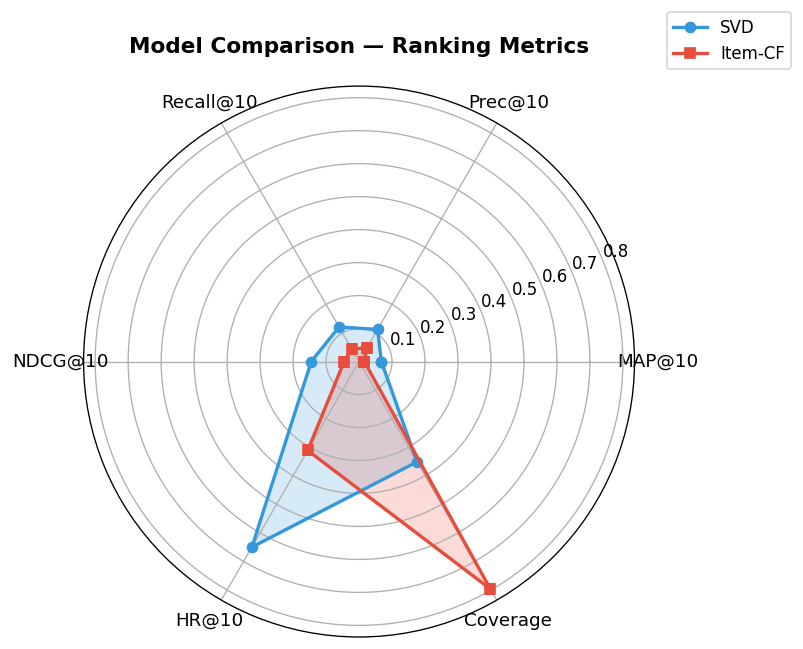

In [44]:
import matplotlib.patches as mpatches

radar_metrics = ['map@10', 'precision@10', 'recall@10',
                 'ndcg@10', 'hit_rate@10', 'coverage']
radar_labels  = ['MAP@10', 'Prec@10', 'Recall@10', 'NDCG@10', 'HR@10', 'Coverage']

svd_vals = [svd_results[m] for m in radar_metrics]
cf_vals  = [cf_results[m]  for m in radar_metrics]

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
svd_vals_c = svd_vals + [svd_vals[0]]
cf_vals_c  = cf_vals  + [cf_vals[0]]
angles_c   = angles   + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles_c, svd_vals_c, 'o-', linewidth=2, color='#3498db', label='SVD')
ax.fill(angles_c, svd_vals_c, alpha=0.2, color='#3498db')
ax.plot(angles_c, cf_vals_c, 's-', linewidth=2, color='#e74c3c', label='Item-CF')
ax.fill(angles_c, cf_vals_c, alpha=0.2, color='#e74c3c')
ax.set_thetagrids(np.degrees(angles), radar_labels, fontsize=11)
ax.set_title('Model Comparison — Ranking Metrics', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

In [46]:
winner_rmse   = 'SVD' if svd_results['rmse'] <= cf_results['rmse'] else 'Item-Based CF'
winner_map    = 'SVD' if svd_results['map@10'] >= cf_results['map@10'] else 'Item-Based CF'
winner_cover  = 'SVD' if svd_results['coverage'] >= cf_results['coverage'] else 'Item-Based CF'

print('=' * 70)
print('  KEY FINDINGS')
print('=' * 70)
print(f"""
1. RATING ACCURACY (RMSE)
   • {winner_rmse} achieves lower RMSE ({min(svd_results['rmse'], cf_results['rmse']):.4f})
   • SVD benefits from bias terms and latent factor regularisation.
   • Item-CF can overfit to popular items, inflating RMSE.

2. RANKING QUALITY (MAP@10)  ← PRIMARY METRIC
   • {winner_map} achieves higher MAP@10 ({max(svd_results['map@10'], cf_results['map@10']):.4f})
   • SVD's continuous latent space allows finer score discrimination.
   • Item-CF ranks items mainly by neighbourhood similarity, which is
     coarser but highly explainable.

3. CATALOG COVERAGE
   • {winner_cover} covers more of the catalog ({max(svd_results['coverage'], cf_results['coverage']):.2%})
   • Item-CF concentrates on popular items; SVD distributes better.

4. COLD-START PROBLEM
   • Both models degrade for users with <5 ratings.
   • Item-CF falls back to popularity-based recommendations.
   • SVD falls back to global mean + item bias.
   • Mitigation: hybrid model, content-based fallback, or asking users
     for explicit preferences during onboarding.

5. EXPLAINABILITY
   • Item-CF is fully interpretable: "You liked X, which is 87%
     similar to Y" — natural for user-facing explanations.
   • SVD's latent factors are opaque; proxy explanations (neighbourhood)
     approximate but don't reflect the actual computation.

6. SCALABILITY
   • SVD scales to large user counts with SGD; Item-CF requires
     storing an (n_items × n_items) matrix which grows quadratically.
   • For production on the full Netflix corpus (17K movies, 480K users)
     SVD or ALS with Alternating Least Squares is preferred.

RECOMMENDATION: Use SVD as the primary model for accuracy and ranking
quality; use Item-CF as an interpretability layer for generating
user-facing explanations alongside SVD predictions.
""")
print('=' * 70)

  KEY FINDINGS

1. RATING ACCURACY (RMSE)
   • SVD achieves lower RMSE (0.9023)
   • SVD benefits from bias terms and latent factor regularisation.
   • Item-CF can overfit to popular items, inflating RMSE.

2. RANKING QUALITY (MAP@10)  ← PRIMARY METRIC
   • SVD achieves higher MAP@10 (0.0677)
   • SVD's continuous latent space allows finer score discrimination.
   • Item-CF ranks items mainly by neighbourhood similarity, which is
     coarser but highly explainable.

3. CATALOG COVERAGE
   • Item-Based CF covers more of the catalog (79.62%)
   • Item-CF concentrates on popular items; SVD distributes better.

4. COLD-START PROBLEM
   • Both models degrade for users with <5 ratings.
   • Item-CF falls back to popularity-based recommendations.
   • SVD falls back to global mean + item bias.
   • Mitigation: hybrid model, content-based fallback, or asking users
     for explicit preferences during onboarding.

5. EXPLAINABILITY
   • Item-CF is fully interpretable: "You liked X, which is 8

Saveing key artifacts

In [47]:
results_df.to_csv('evaluation_results.csv')

# Sample recommendations to CSV (first 100 users, both models)
rows = []
for uid in test_users[:100]:
    for rank, mid in enumerate(svd_recs.get(uid, [])[:TOP_K], 1):
        rows.append({'user_id': uid, 'model': 'SVD', 'rank': rank,
                     'movie_id': mid, 'title': movie_titles.get(mid, str(mid)),
                     'pred_rating': svd.predict(uid, mid)})
    for rank, mid in enumerate(cf_recs.get(uid, [])[:TOP_K], 1):
        rows.append({'user_id': uid, 'model': 'Item-CF', 'rank': rank,
                     'movie_id': mid, 'title': movie_titles.get(mid, str(mid)),
                     'pred_rating': item_cf.predict(uid, mid)})

recs_export = pd.DataFrame(rows)
recs_export.to_csv('sample_recommendations.csv', index=False)

print('✓ Saved evaluation_results.csv')
print('✓ Saved sample_recommendations.csv')
print('\nDone! 🎬')

✓ Saved evaluation_results.csv
✓ Saved sample_recommendations.csv

Done! 🎬
